In [3]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

![Task 1](images/task1.png)

In [4]:
data=pd.read_csv('data/sales_data.csv')
data.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [5]:
data.shape

(1000, 14)

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   str    
 2   Sales_Rep             1000 non-null   str    
 3   Region                1000 non-null   str    
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   str    
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   str    
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   str    
 12  Sales_Channel         1000 non-null   str    
 13  Region_and_Sales_Rep  1000 non-null   str    
dtypes: float64(4), int64(2), str(8)
memory usage: 166.7 KB


In [7]:
data['Sale_Date']=pd.to_datetime(data['Sale_Date'])

In [8]:
data['Month']=data['Sale_Date'].dt.month_name()

In [9]:
data['Month'].unique()

<ArrowStringArray>
[ 'February',     'April', 'September',    'August',     'March',   'January',
      'June',   'October',  'November',  'December',       'May',      'July']
Length: 12, dtype: str

In [10]:
sales_month=data.groupby('Month')['Sales_Amount'].sum()

In [11]:
sales_month

Month
April        438992.61
August       443171.28
December     392643.58
February     368919.36
January      495420.37
July         374242.88
June         418458.34
March        402638.77
May          389078.76
November     467482.90
October      460378.78
September    367837.60
Name: Sales_Amount, dtype: float64

In [12]:
sales_month.index=pd.CategoricalIndex(sales_month.index,categories=['January','February','March','April','May','June','July','August','September','October','November','December'])

In [13]:
sales_month=sales_month.sort_index()

In [14]:
sales_month

Month
January      495420.37
February     368919.36
March        402638.77
April        438992.61
May          389078.76
June         418458.34
July         374242.88
August       443171.28
September    367837.60
October      460378.78
November     467482.90
December     392643.58
Name: Sales_Amount, dtype: float64

In [15]:
#plotting line plot
x=sales_month.index
y=sales_month.values

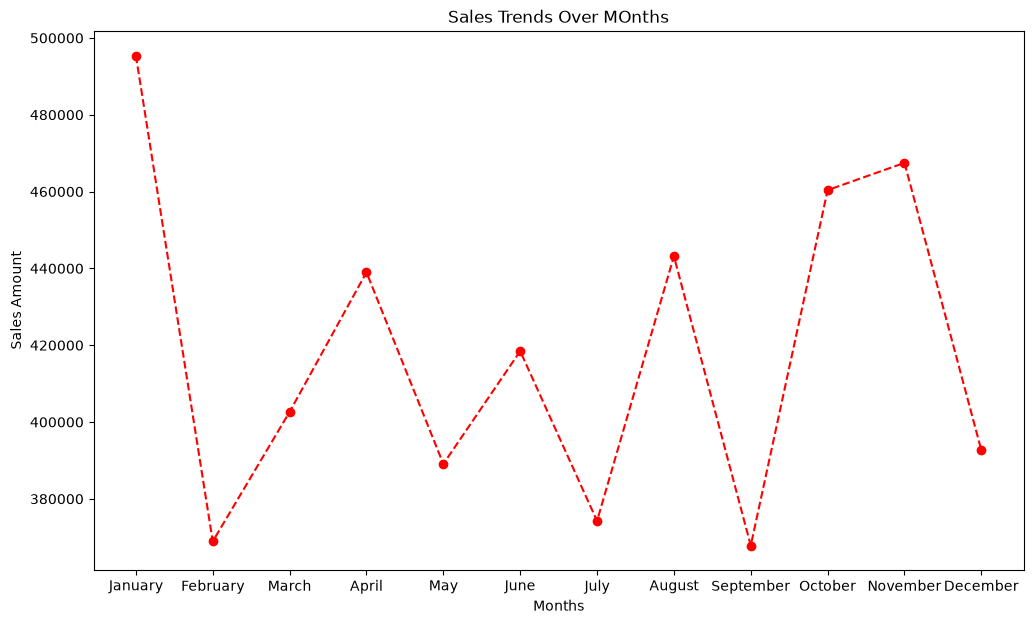

In [16]:
plt.figure(figsize=(12,7))
plt.title('Sales Trends Over MOnths')
plt.xlabel('Months')
plt.ylabel('Sales Amount')
plt.plot(x,y,marker='o',color='red',linestyle='--')
plt.show()

![Task 1](images/task2.png)

In [17]:
data.head(5)

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Month
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,February
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,April
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David,September
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob,August
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,March


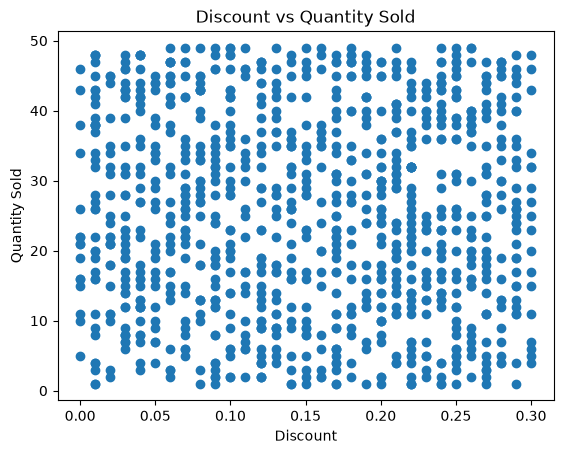

In [18]:
plt.title('Discount vs Quantity Sold')
plt.xlabel('Discount')
plt.ylabel('Quantity Sold')
plt.scatter(data=data,x='Discount',y='Quantity_Sold')

![Task 1](images/task3.png)

In [19]:
data['Sales_Channel'].value_counts()

Sales_Channel
Retail    512
Online    488
Name: count, dtype: int64

In [20]:
count=data.groupby('Sales_Channel')['Product_ID'].count()

In [21]:
x=count.index
y=count.values

/var/folders/c1/6c8s3wn93nd1yg_s50mdh4nc0000gn/T/ipykernel_1323/3747937832.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


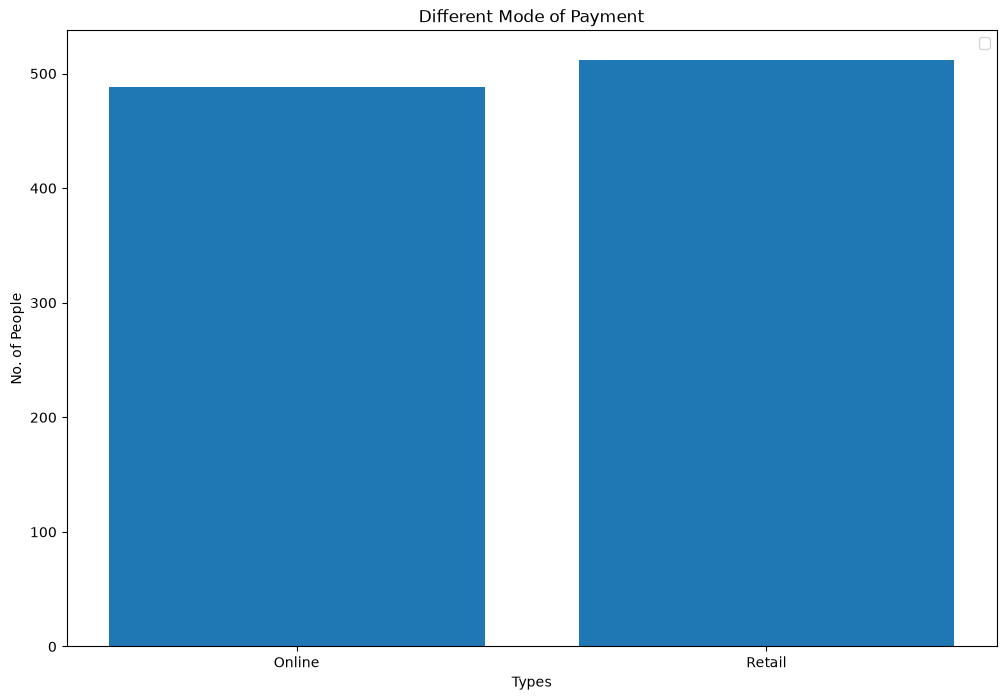

In [22]:
plt.figure(figsize=(12,8))
plt.title('Different Mode of Payment')
plt.xlabel("Types")
plt.ylabel('No. of People')
plt.legend()
plt.bar(x,y)
plt.show()

<BarContainer object of 2 artists>

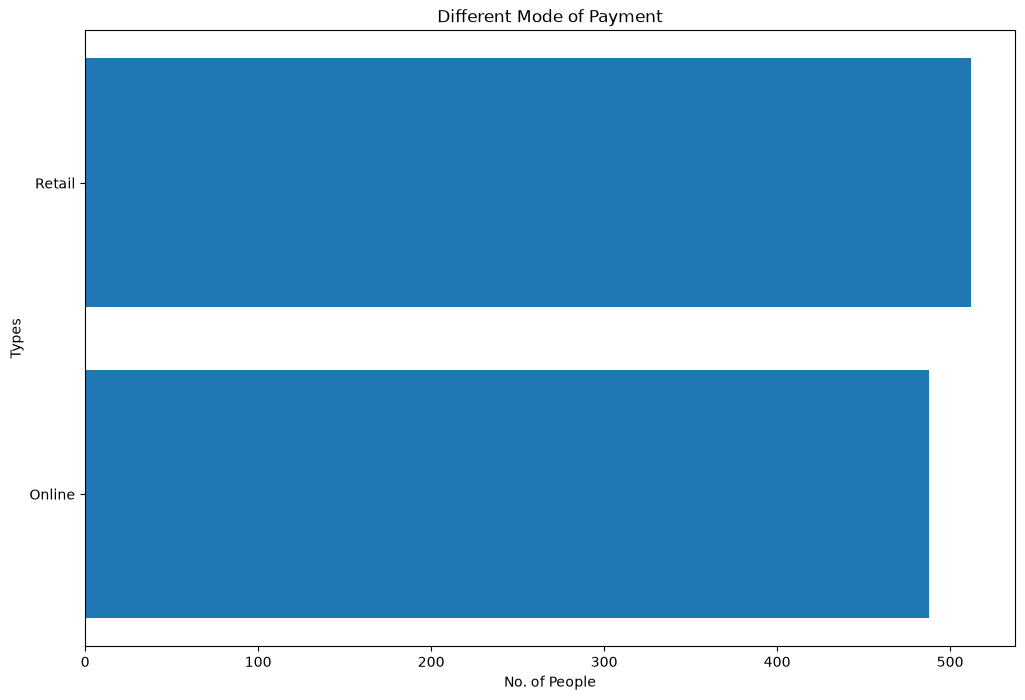

In [23]:
plt.figure(figsize=(12,8))
plt.title('Different Mode of Payment')
plt.ylabel("Types")
plt.xlabel('No. of People')
plt.barh(x,y)

![Task 1](images/task4.png)

In [24]:
p=data.groupby('Month')['Sales_Amount'].sum()

In [25]:
p

Month
April        438992.61
August       443171.28
December     392643.58
February     368919.36
January      495420.37
July         374242.88
June         418458.34
March        402638.77
May          389078.76
November     467482.90
October      460378.78
September    367837.60
Name: Sales_Amount, dtype: float64

In [26]:
p.index=pd.CategoricalIndex(p.index,categories=['January','February','March','April','May','June','July','August','September','October','November','December'])
p=p.sort_index()

In [27]:
x=p.index.astype('str')
y=p.values

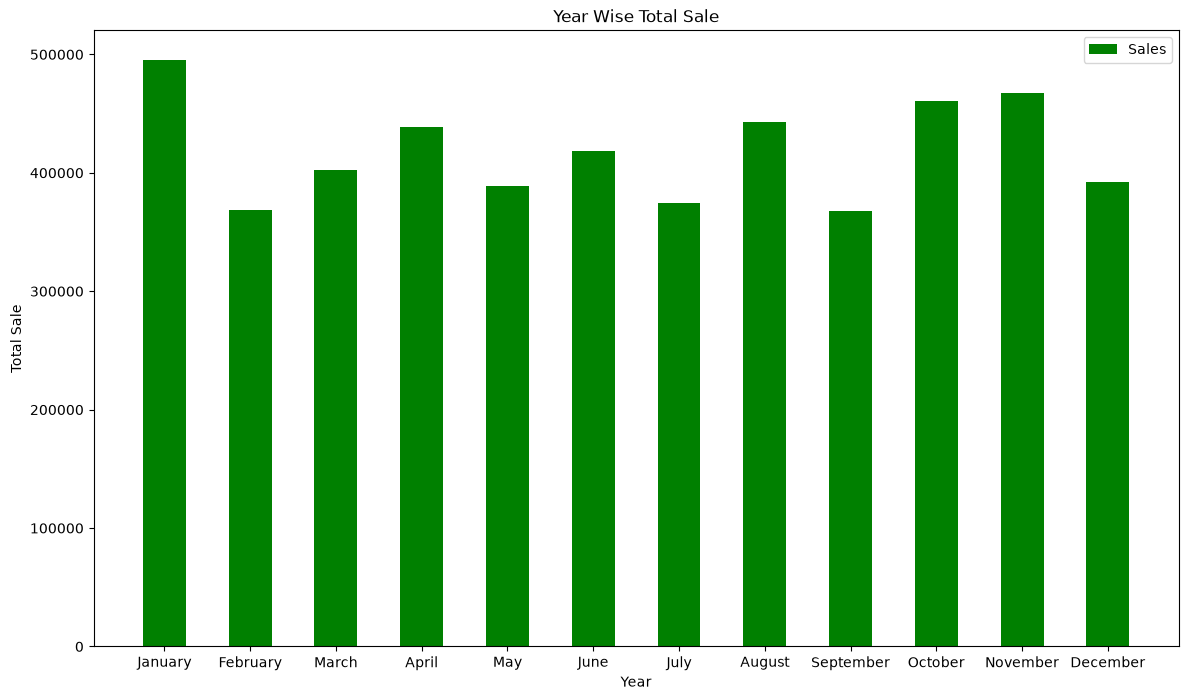

In [28]:
plt.figure(figsize=(14,8))
plt.title('Year Wise Total Sale')
plt.xlabel('Year')
plt.ylabel('Total Sale')
plt.bar(x,y,width=0.5,color='green',label='Sales')
plt.legend()
plt.show()

![Task 1](images/task5.png)

In [29]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Product_ID            1000 non-null   int64         
 1   Sale_Date             1000 non-null   datetime64[us]
 2   Sales_Rep             1000 non-null   str           
 3   Region                1000 non-null   str           
 4   Sales_Amount          1000 non-null   float64       
 5   Quantity_Sold         1000 non-null   int64         
 6   Product_Category      1000 non-null   str           
 7   Unit_Cost             1000 non-null   float64       
 8   Unit_Price            1000 non-null   float64       
 9   Customer_Type         1000 non-null   str           
 10  Discount              1000 non-null   float64       
 11  Payment_Method        1000 non-null   str           
 12  Sales_Channel         1000 non-null   str           
 13  Region_and_Sales_Rep  1000 non

In [30]:
data['Region'].value_counts()

Region
North    267
East     263
West     244
South    226
Name: count, dtype: int64

In [31]:
data['Product_Category'].value_counts()

Product_Category
Clothing       268
Furniture      260
Electronics    246
Food           226
Name: count, dtype: int64

In [32]:
Clothing=data[data['Product_Category']=='Clothing']
Furniture=data[data['Product_Category']=='Furniture']
Electronics=data[data['Product_Category']=='Electronics']
Food=data[data['Product_Category']=='Food']

In [33]:
Clothing=Clothing.groupby('Region')['Quantity_Sold'].sum()
Furniture=Furniture.groupby('Region')['Quantity_Sold'].sum()
Electronics=Electronics.groupby('Region')['Quantity_Sold'].sum()
Food=Food.groupby('Region')['Quantity_Sold'].sum()

In [34]:
Clothing.index

Index(['East', 'North', 'South', 'West'], dtype='str', name='Region')

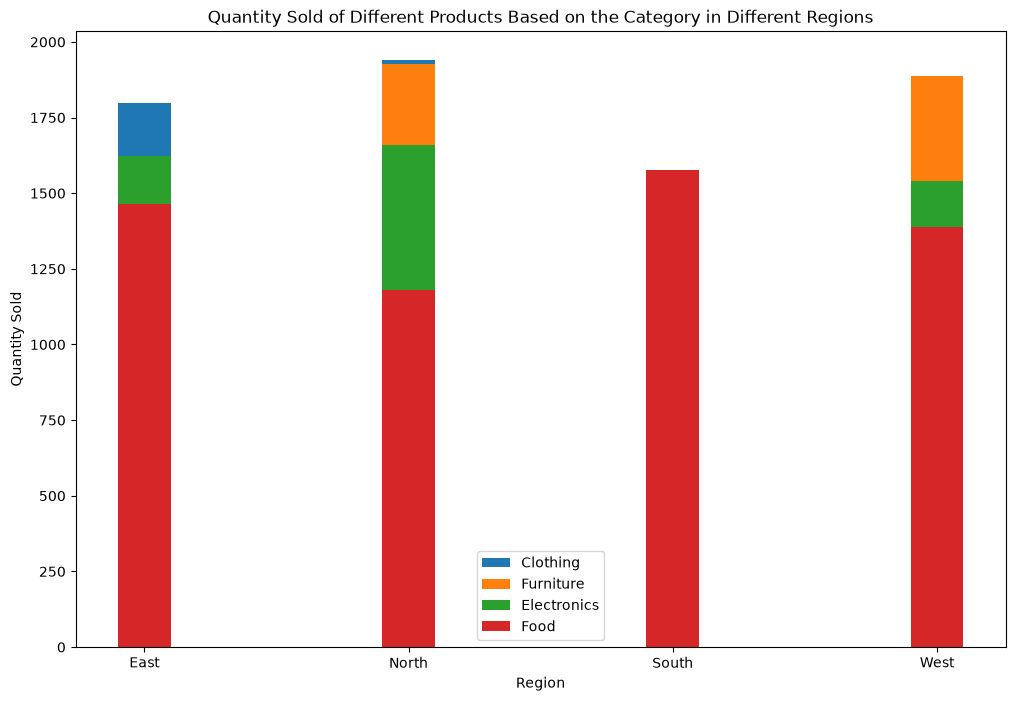

In [35]:
plt.figure(figsize=(12,8))
plt.xlabel('Region')
plt.ylabel('Quantity Sold')
plt.title('Quantity Sold of Different Products Based on the Category in Different Regions')
plt.bar(Clothing.index,Clothing.values,width=0.2,label='Clothing')
plt.bar(Furniture.index,Furniture.values,width=0.2,label='Furniture')
plt.bar(Electronics.index,Electronics.values,width=0.2,label='Electronics')
plt.bar(Food.index,Food.values,width=0.2,label='Food')
plt.legend()
plt.show()

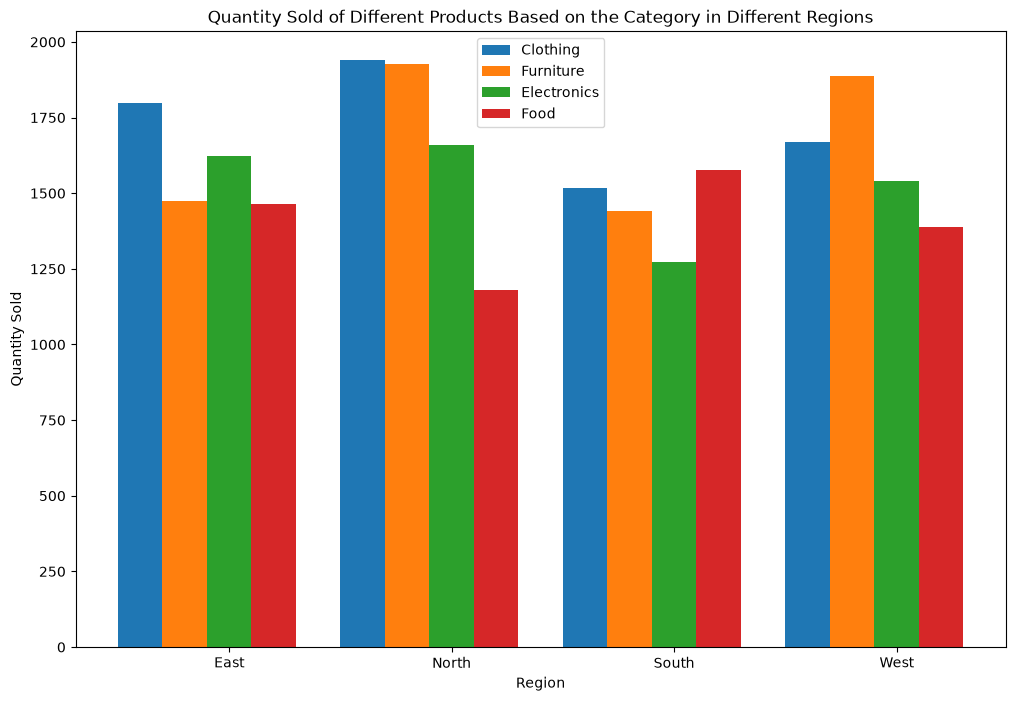

In [36]:
plt.figure(figsize=(12,8))
plt.xlabel('Region')
plt.ylabel('Quantity Sold')
plt.title('Quantity Sold of Different Products Based on the Category in Different Regions')

x=np.arange(len(Food.index))
plt.bar(x-0.4,Clothing.values,width=0.2,label='Clothing')
plt.bar(x-0.2,Furniture.values,width=0.2,label='Furniture')
plt.bar(x,Electronics.values,width=0.2,label='Electronics')
plt.bar(x+0.2,Food.values,width=0.2,label='Food')
plt.xticks(x,Food.index)
plt.legend()
plt.show()

![Task 1](images/task6.png)

In [37]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Product_ID            1000 non-null   int64         
 1   Sale_Date             1000 non-null   datetime64[us]
 2   Sales_Rep             1000 non-null   str           
 3   Region                1000 non-null   str           
 4   Sales_Amount          1000 non-null   float64       
 5   Quantity_Sold         1000 non-null   int64         
 6   Product_Category      1000 non-null   str           
 7   Unit_Cost             1000 non-null   float64       
 8   Unit_Price            1000 non-null   float64       
 9   Customer_Type         1000 non-null   str           
 10  Discount              1000 non-null   float64       
 11  Payment_Method        1000 non-null   str           
 12  Sales_Channel         1000 non-null   str           
 13  Region_and_Sales_Rep  1000 non

In [38]:
data['Discount'].median()

np.float64(0.15)

In [39]:
data['Discount'].min()

np.float64(0.0)

In [41]:
data['Discount'].max()

np.float64(0.3)

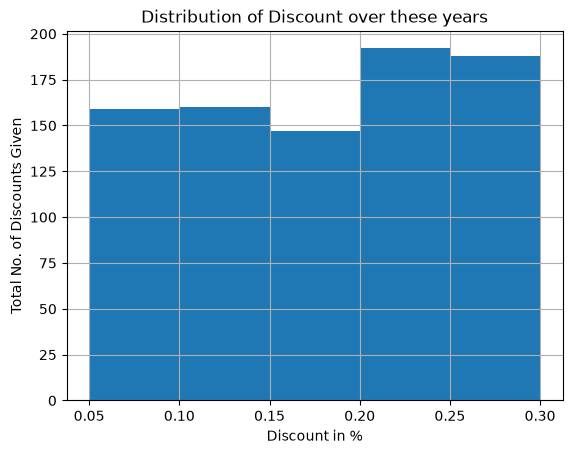

In [50]:
plt.title('Distribution of Discount over these years')
plt.xlabel('Discount in %')
plt.ylabel('Total No. of Discounts Given')
plt.hist(data['Discount'],bins=[0.05,0.10,0.15,0.2,0.25,0.3])
plt.grid()
plt.show()

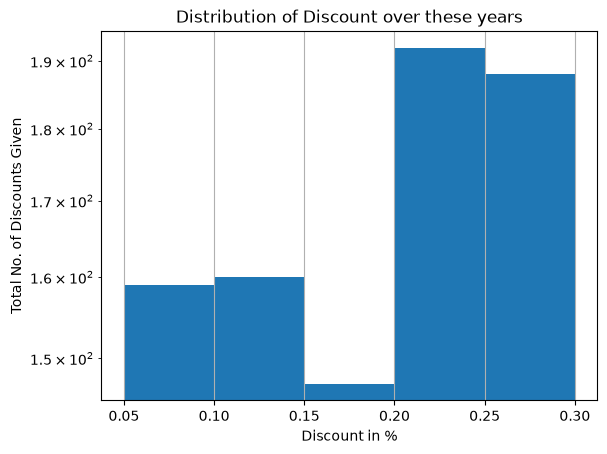

In [51]:
plt.title('Distribution of Discount over these years')
plt.xlabel('Discount in %')
plt.ylabel('Total No. of Discounts Given')
plt.hist(data['Discount'],bins=[0.05,0.10,0.15,0.2,0.25,0.3],log=True)
plt.grid()
plt.show()

![Task 1](images/task7.png)

In [60]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Product_ID            1000 non-null   int64         
 1   Sale_Date             1000 non-null   datetime64[us]
 2   Sales_Rep             1000 non-null   str           
 3   Region                1000 non-null   str           
 4   Sales_Amount          1000 non-null   float64       
 5   Quantity_Sold         1000 non-null   int64         
 6   Product_Category      1000 non-null   str           
 7   Unit_Cost             1000 non-null   float64       
 8   Unit_Price            1000 non-null   float64       
 9   Customer_Type         1000 non-null   str           
 10  Discount              1000 non-null   float64       
 11  Payment_Method        1000 non-null   str           
 12  Sales_Channel         1000 non-null   str           
 13  Region_and_Sales_Rep  1000 non

In [53]:
data['Region'].value_counts()

Region
North    267
East     263
West     244
South    226
Name: count, dtype: int64

In [59]:
data['Region'].dtype

<StringDtype(na_value=nan)>

In [61]:
x=data.groupby('Region')['Sales_Amount'].sum()

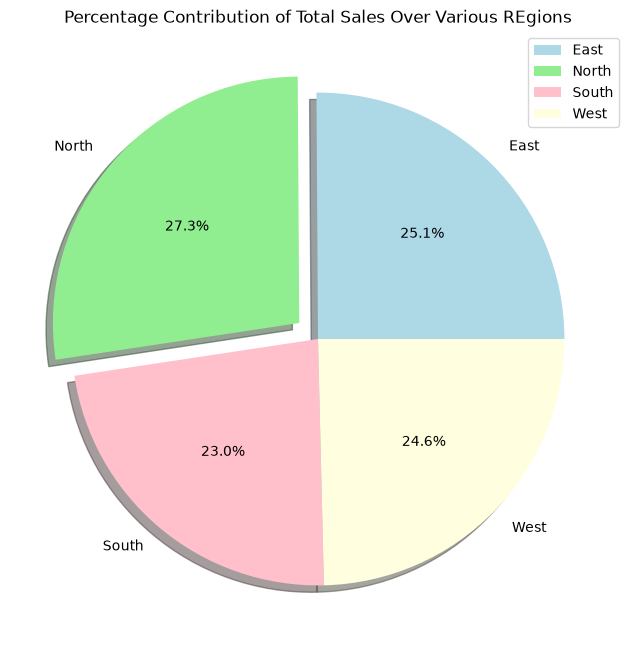

In [81]:
plt.figure(figsize=(12,8))
plt.title('Percentage Contribution of Total Sales Over Various REgions')
plt.pie(x,labels=x.index,autopct='%0.1f%%',colors=['lightblue','lightgreen','pink','lightyellow'],explode=[0,0.1,0,0],shadow=True)
plt.legend()
plt.show()